In [1]:
import pandas as pd

data = pd.read_csv('data/img-metadata-CC0.csv')

data.head()

/tmp/ipykernel_135264/1890517993.py:3: DtypeWarning: Columns (0: find_spot) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/img-metadata-CC0.csv')


,id,accession_number,share_license_status,tombstone,current_location,title,title_in_original_language,series,series_in_original_language,creation_date,...,creditline,image_credit,sketchfab_id,sketchfab_url,gallery_donor_text,creators,image_web,image_print,image_full,updated_at
0,74228,2020.113,CC0,"Fishmarket, 1902. Camille Pissarro (French, 18...",NaN,Fishmarket,NaN,NaN,NaN,1902,...,Nancy F. and Joseph P. Keithley Collection Gift,NaN,NaN,NaN,NaN,"Camille Pissarro (French, 1830–1903), artist",https://openaccess-cdn.clevelandart.org/2020.1...,https://openaccess-cdn.clevelandart.org/2020.1...,https://openaccess-cdn.clevelandart.org/2020.1...,2026-05-12 11:10:13.854000
1,74539,2015.449,CC0,"A Miller's Carriage, c. 1895. Albert-Charles L...",NaN,A Miller's Carriage,NaN,NaN,NaN,c. 1895,...,Bequest of Muriel Butkin,NaN,NaN,NaN,NaN,"Albert-Charles Lebourg (French, 1849–1928), ar...",https://openaccess-cdn.clevelandart.org/2015.4...,https://openaccess-cdn.clevelandart.org/2015.4...,https://openaccess-cdn.clevelandart.org/2015.4...,2026-05-01 06:45:19.614000
2,74540,2015.451,CC0,"Leda and the Swan, c. 1846–83. Adolphe Yvon (F...",NaN,Leda and the Swan,NaN,NaN,NaN,c. 1846–83,...,Bequest of Muriel Butkin,NaN,NaN,NaN,NaN,"Adolphe Yvon (French, 1817–1893), artist",https://openaccess-cdn.clevelandart.org/2015.4...,https://openaccess-cdn.clevelandart.org/2015.4...,https://openaccess-cdn.clevelandart.org/2015.4...,2026-05-01 06:45:19.627000
3,74551,2018.1059,CC0,"The Monks, c. 1802–30. François Marius Granet ...",NaN,The Monks,NaN,NaN,NaN,c. 1802–30,...,Bequest of Muriel Butkin,NaN,NaN,NaN,NaN,"François Marius Granet (French, 1775–1849), ar...",https://openaccess-cdn.clevelandart.org/2018.1...,https://openaccess-cdn.clevelandart.org/2018.1...,https://openaccess-cdn.clevelandart.org/2018.1...,2026-05-01 06:45:19.652000
4,74553,2018.1060,CC0,"Study Sheet, c. 1870–80. Alfred Dehodencq (Fre...",NaN,Study Sheet,NaN,NaN,NaN,c. 1870–80,...,Bequest of Muriel Butkin,NaN,NaN,NaN,NaN,"Alfred Dehodencq (French, 1822–1882), artist",https://openaccess-cdn.clevelandart.org/2018.1...,https://openaccess-cdn.clevelandart.org/2018.1...,https://openaccess-cdn.clevelandart.org/2018.1...,2026-05-01 06:45:19.668000


In [2]:
types = data['type'].unique()
data['type'].value_counts()

type
Print         10698
Painting       3951
Drawing        1990
Sculpture      1976
Photograph      988
Portfolio       428
Sampler          84
Tapestry         56
Mosaic            6
Name: count, dtype: int64

/home/arjun/projects/ArtButSports/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


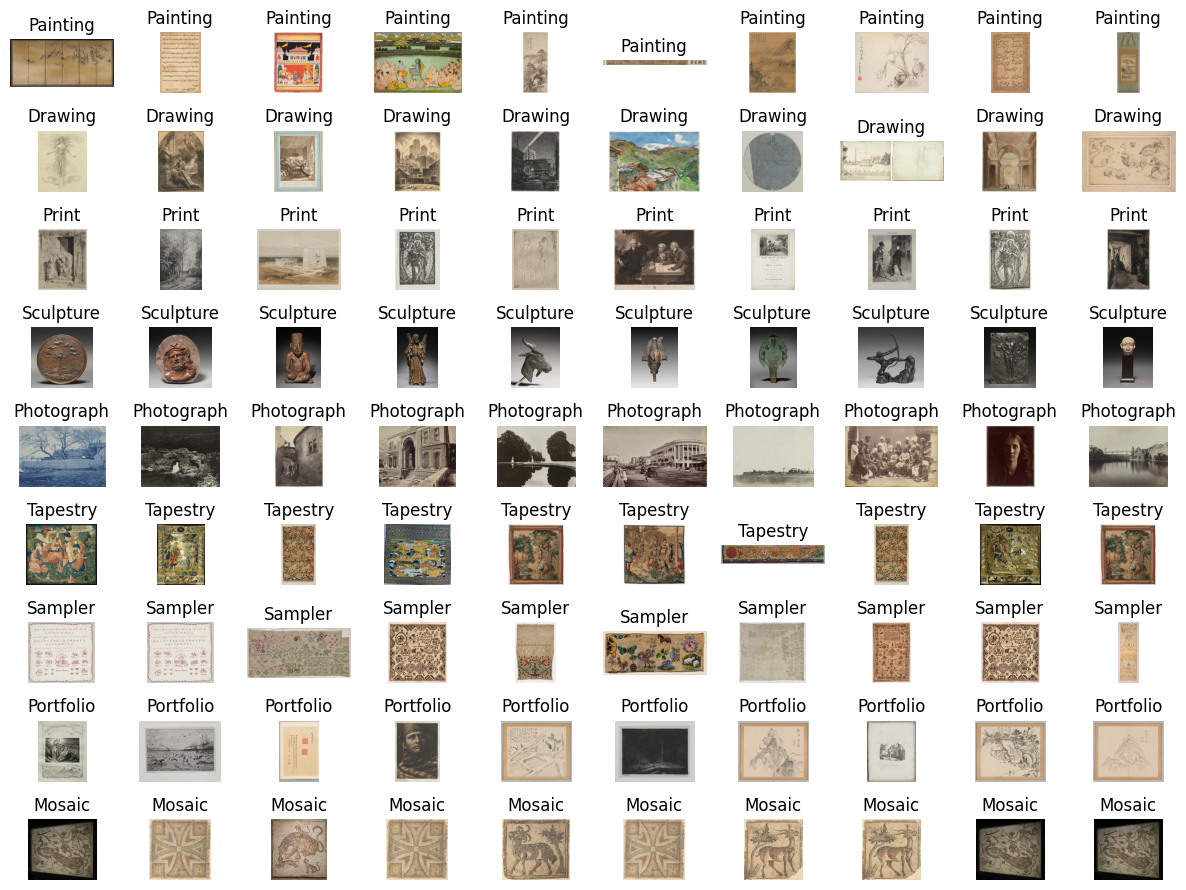

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
from io import BytesIO
from tqdm.contrib.concurrent import thread_map

def fetch_image(subplot_idx, title, url):
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response:
        image = plt.imread(BytesIO(response.read()), format='jpg')
    return subplot_idx, title, image

plt.figure(figsize=(12, len(types)))

tasks = []
for i, t in enumerate(types):
    # 10 images per type in a row
    urls = np.random.choice(data[data['type'] == t]['image_web'].tolist(), 10)
    for j, url in enumerate(urls):
        tasks.append((i * 10 + j + 1, t, url))

results = thread_map(
    lambda args: fetch_image(*args),
    tasks,
    max_workers=16,
    desc='Downloading images',
)

for subplot_idx, t, image in results:
    plt.subplot(len(types), 10, subplot_idx)
    plt.imshow(image)
    plt.axis('off')
    plt.title(t)

plt.tight_layout()
plt.show()



In [4]:
keep = ["Portfolio", "Mosaic", "Sampler", "Tapestry", "Photograph", "Sculpture", "Print", "Drawing", "Painting"]

data = data[data['type'].isin(keep)]
data.head()

,id,accession_number,share_license_status,tombstone,current_location,title,title_in_original_language,series,series_in_original_language,creation_date,...,creditline,image_credit,sketchfab_id,sketchfab_url,gallery_donor_text,creators,image_web,image_print,image_full,updated_at
0,74228,2020.113,CC0,"Fishmarket, 1902. Camille Pissarro (French, 18...",NaN,Fishmarket,NaN,NaN,NaN,1902,...,Nancy F. and Joseph P. Keithley Collection Gift,NaN,NaN,NaN,NaN,"Camille Pissarro (French, 1830–1903), artist",https://openaccess-cdn.clevelandart.org/2020.1...,https://openaccess-cdn.clevelandart.org/2020.1...,https://openaccess-cdn.clevelandart.org/2020.1...,2026-05-12 11:10:13.854000
1,74539,2015.449,CC0,"A Miller's Carriage, c. 1895. Albert-Charles L...",NaN,A Miller's Carriage,NaN,NaN,NaN,c. 1895,...,Bequest of Muriel Butkin,NaN,NaN,NaN,NaN,"Albert-Charles Lebourg (French, 1849–1928), ar...",https://openaccess-cdn.clevelandart.org/2015.4...,https://openaccess-cdn.clevelandart.org/2015.4...,https://openaccess-cdn.clevelandart.org/2015.4...,2026-05-01 06:45:19.614000
2,74540,2015.451,CC0,"Leda and the Swan, c. 1846–83. Adolphe Yvon (F...",NaN,Leda and the Swan,NaN,NaN,NaN,c. 1846–83,...,Bequest of Muriel Butkin,NaN,NaN,NaN,NaN,"Adolphe Yvon (French, 1817–1893), artist",https://openaccess-cdn.clevelandart.org/2015.4...,https://openaccess-cdn.clevelandart.org/2015.4...,https://openaccess-cdn.clevelandart.org/2015.4...,2026-05-01 06:45:19.627000
3,74551,2018.1059,CC0,"The Monks, c. 1802–30. François Marius Granet ...",NaN,The Monks,NaN,NaN,NaN,c. 1802–30,...,Bequest of Muriel Butkin,NaN,NaN,NaN,NaN,"François Marius Granet (French, 1775–1849), ar...",https://openaccess-cdn.clevelandart.org/2018.1...,https://openaccess-cdn.clevelandart.org/2018.1...,https://openaccess-cdn.clevelandart.org/2018.1...,2026-05-01 06:45:19.652000
4,74553,2018.1060,CC0,"Study Sheet, c. 1870–80. Alfred Dehodencq (Fre...",NaN,Study Sheet,NaN,NaN,NaN,c. 1870–80,...,Bequest of Muriel Butkin,NaN,NaN,NaN,NaN,"Alfred Dehodencq (French, 1822–1882), artist",https://openaccess-cdn.clevelandart.org/2018.1...,https://openaccess-cdn.clevelandart.org/2018.1...,https://openaccess-cdn.clevelandart.org/2018.1...,2026-05-01 06:45:19.668000


In [5]:
data['type'].value_counts()

type
Print         10698
Painting       3951
Drawing        1990
Sculpture      1976
Photograph      988
Portfolio       428
Sampler          84
Tapestry         56
Mosaic            6
Name: count, dtype: int64

In [6]:
departments = data['department'].unique()
data['department'].value_counts()

department
Prints                                    10160
Indian and Southeast Asian Art             2203
Drawings                                   1900
Japanese Art                               1350
Photography                                1131
Chinese Art                                 798
European Painting and Sculpture             637
Modern European Painting and Sculpture      449
Medieval Art                                287
American Painting and Sculpture             278
Art of the Americas                         218
Egyptian and Ancient Near Eastern Art       184
Greek and Roman Art                         182
Textiles                                    150
African Art                                 112
Korean Art                                   73
Islamic Art                                  34
Oceania                                      27
Decorative Art and Design                     4
Name: count, dtype: int64

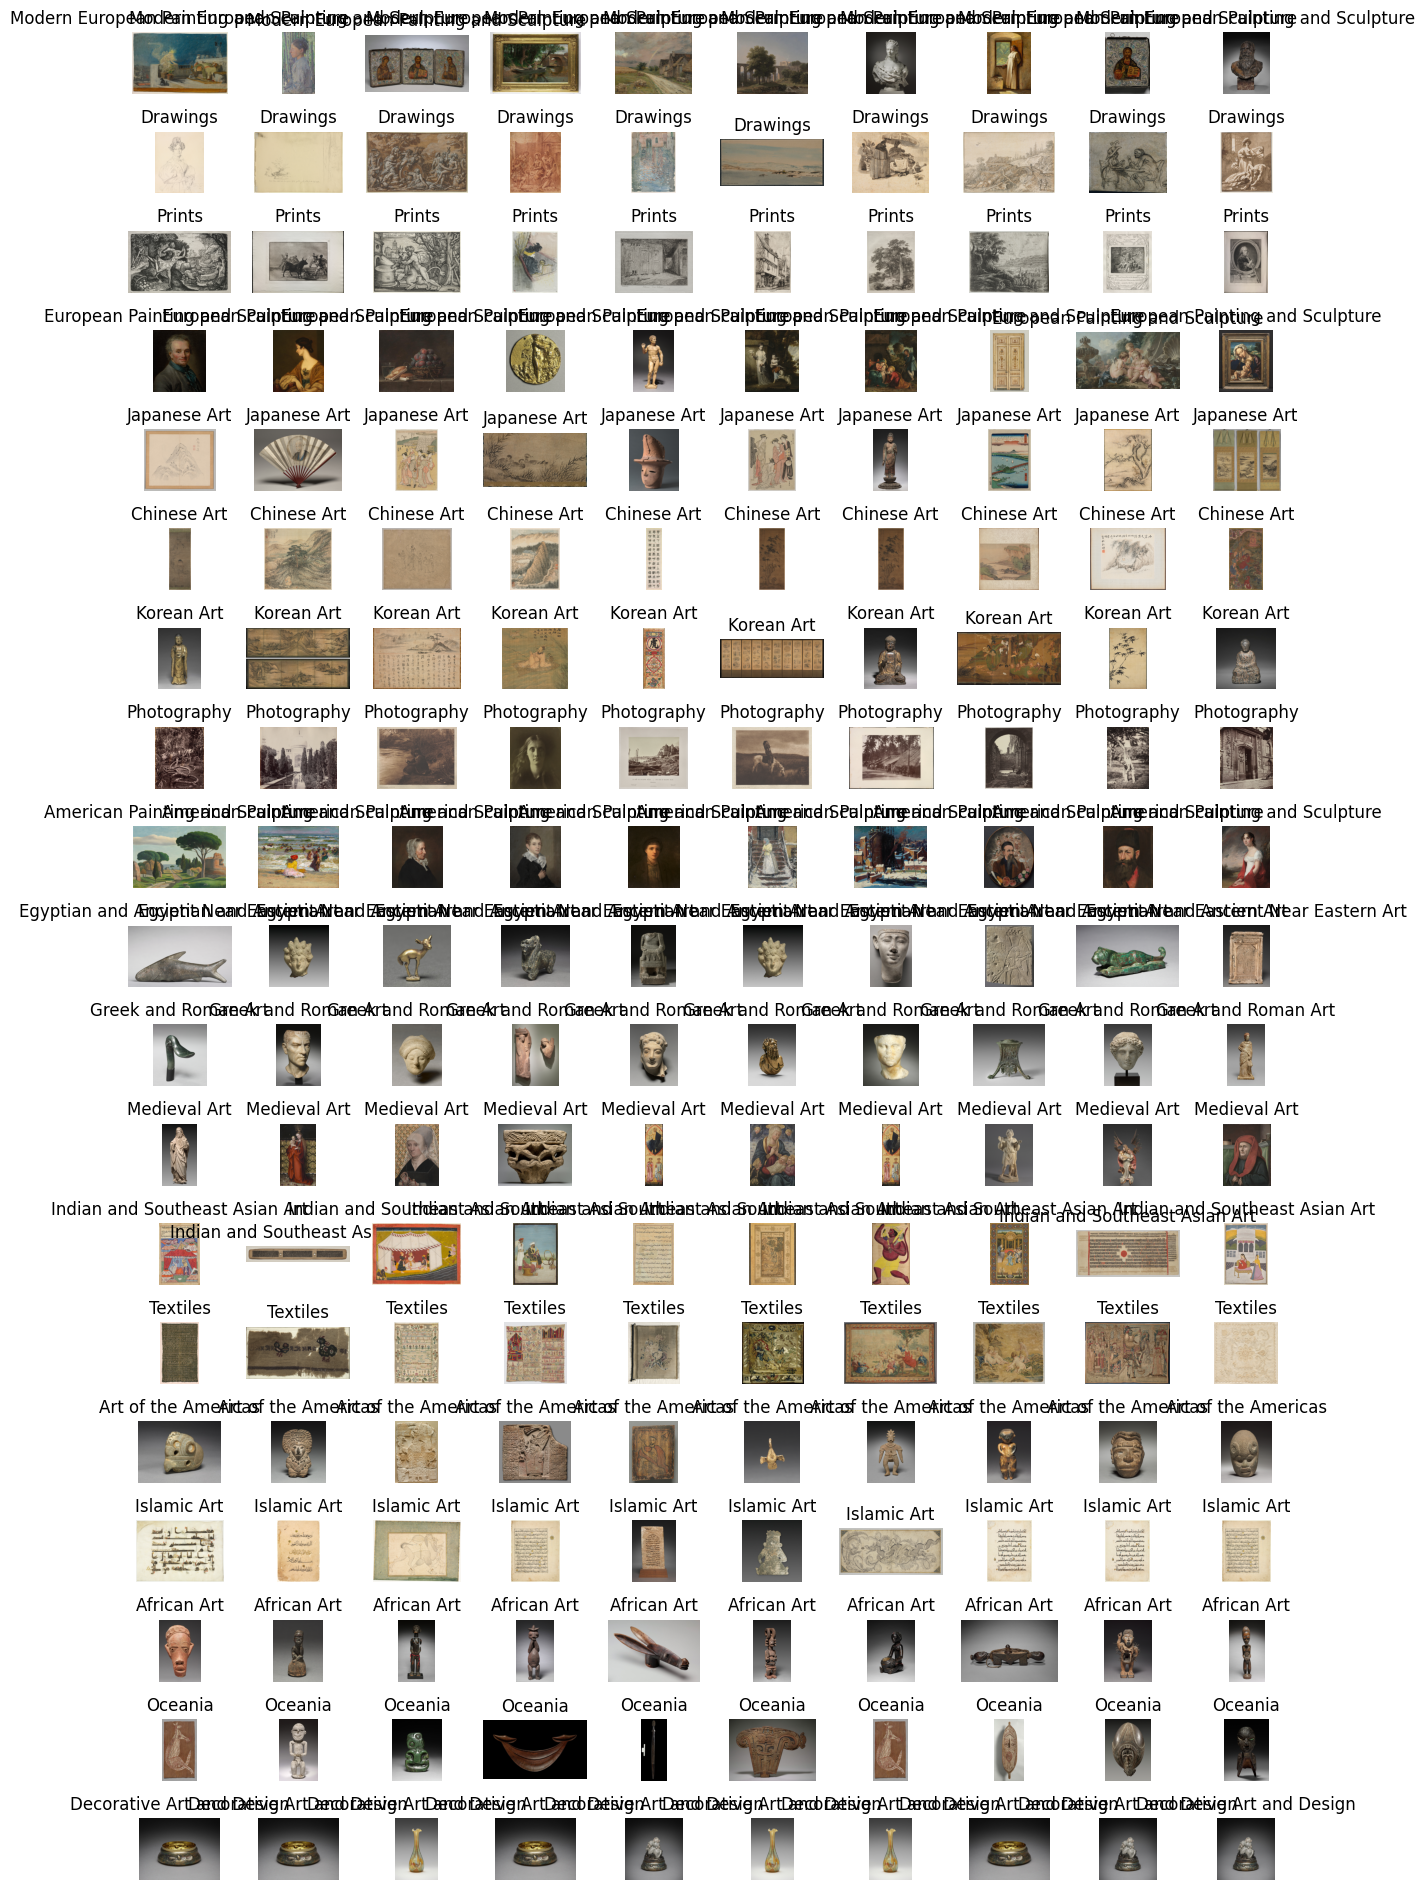

In [7]:
plt.figure(figsize=(12, len(departments)))

tasks = []

for i, d in enumerate(departments):
    urls = np.random.choice(data[data['department'] == d]['image_web'].tolist(), 10)
    for j, url in enumerate(urls):
        tasks.append((i * 10 + j + 1, d, url))

results = thread_map(
    lambda args: fetch_image(*args),
    tasks,
    max_workers=16,
    desc='Downloading images',
)

for subplot_idx, d, image in results:
    plt.subplot(len(departments), 10, subplot_idx)
    plt.imshow(image)
    plt.axis('off')
    plt.title(d)

plt.tight_layout()
plt.show()

In [8]:
remove = ["Islamic Art", "Decorative Art and Design", "African Art", "Oceania"]

data = data[~data['department'].isin(remove)]
data['department'].value_counts()

department
Prints                                    10160
Indian and Southeast Asian Art             2203
Drawings                                   1900
Japanese Art                               1350
Photography                                1131
Chinese Art                                 798
European Painting and Sculpture             637
Modern European Painting and Sculpture      449
Medieval Art                                287
American Painting and Sculpture             278
Art of the Americas                         218
Egyptian and Ancient Near Eastern Art       184
Greek and Roman Art                         182
Textiles                                    150
Korean Art                                   73
Name: count, dtype: int64

In [9]:
data.to_csv('data/img-metadata-CC0-clean.csv', index=False)